## Model 2 – CTC Unit Encoder + BiLSTM Syllable Classifier

Model‑2 is a two-stage neural recognition model for Myanmar handwriting recognition.

In the first stage, a **BiLSTM encoder** is trained with **CTC** to predict a variable-length unit sequence from the input stroke embeddings. This allows the model to learn a meaningful intermediate unit-level representation without requiring explicit alignment between strokes and units.

In the second stage, the learned encoder is reused to build a **syllable classifier**. A BiLSTM classification head is trained on top of the encoder outputs, using masked pooling to predict the final syllable label.

This design separates the learning process into two parts:

1. **Unit learning with CTC**  
   Learns a unit bottleneck from stroke embeddings.

2. **Syllable classification**  
   Uses the learned encoder representation to classify the whole sample into a final syllable.

Compared with Model‑1, Model‑2 replaces classical hybrid scoring with a fully neural two-stage pipeline. It learns both unit-level and syllable-level structure directly from the data.


```mermaid
flowchart TD
    A[Stroke embeddings] --> B[Shared BiLSTM Encoder]

    B --> C[CTC Unit Head]
    C --> D[Unit sequence training with CTC]
    C --> E[Predicted unit sequence]

    B --> F[Encoder features]
    F --> G[BiLSTM Syllable Head]
    G --> H[Masked mean / max pooling]
    H --> I[MLP classifier]
    I --> J[Predicted syllable]

```

In [8]:
#Font for matplot

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/truetype/mm/Pyidaungsu-2.3_Regular.ttf"

fm.fontManager.addfont(font_path)

prop = fm.FontProperties(fname=font_path)

plt.rcParams['font.family'] = prop.get_name()

### DataSet Loading
Strokes ( series of x, y, timestamp ) infromation are load to Pandas Dataframe.

In [9]:
# @title Load Dataset
from load_dataset import get_syllable_df, load_all_strokes, build_train_df

syl_path = '../syl.txt'
hw_path = '../dataset/Aung_Hein/'

processed_df, syllable_df, stroke_df, char2idx, idx2char = build_train_df(syl_path, hw_path)

In [10]:
from writing_units import (
    WritingUnitConfig,
    add_unit_array_columns,
    summarize_unit_conversion,
    add_align_array_columns
)

unit_cfg = WritingUnitConfig(
    merge_base_asat=True,
    merge_virama_next_base=True,
    keep_unit_meta=True,
    annotate_role_in_unit_string=False,
)

processed_units_df = add_unit_array_columns(
    processed_df,
    char_array_col="char_array",
    syllable_col="syllable",
    config=unit_cfg,
)

processed_units_df = add_align_array_columns(processed_units_df)

processed_units_df['sample_index'] = processed_units_df.index

In [11]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    processed_units_df,
    test_size=0.20,
    random_state=42,
    shuffle=True,
)

print("Train rows:", len(train_df))
print("Test rows :", len(test_df))

Train rows: 10570
Test rows : 2643


In [12]:
syllable_df = (
    processed_units_df[["syllable", "char_array"]]
    .drop_duplicates("syllable")
    .reset_index(drop=True)
)

print("Num unique syllables:", len(syllable_df))

Num unique syllables: 4377


## Embedding

In [13]:
import embedding
import importlib
importlib.reload(embedding)

from embedding import embed_stroke_dataframe, stack_embeddings, StrokeEmbeddingConfig


train_emb_df = embed_stroke_dataframe(train_df)
test_emb_df  = embed_stroke_dataframe(test_df)
full_emb_df  = embed_stroke_dataframe(processed_units_df)

In [14]:
from nn_unit_syllable_pipeline import ModelConfig,DataPrepConfig,TrainConfig
data_cfg = DataPrepConfig(
    sample_index_col="sample_index",
    stroke_index_col="stroke_index",
    emb_col="embedding",
    syllable_col="syllable",
    unit_array_col="align_unit_array",
)

In [15]:
import numpy as np

ids = np.array(sorted(train_emb_df["sample_index"].unique()))
rng = np.random.default_rng(42)
rng.shuffle(ids)

n_val = max(1, int(0.1 * len(ids)))
val_ids = set(ids[:n_val])
train_ids = set(ids[n_val:])

train_emb_df_sub = train_emb_df[train_emb_df.sample_index.isin(train_ids)]
val_emb_df_sub   = train_emb_df[train_emb_df.sample_index.isin(val_ids)]

train_meta_df_sub = train_df[train_df.sample_index.isin(train_ids)]
val_meta_df_sub   = train_df[train_df.sample_index.isin(val_ids)]

train_syll_set = set(train_meta_df_sub["syllable"].astype(str).unique())

val_meta_df_seen = val_meta_df_sub[
    val_meta_df_sub["syllable"].astype(str).isin(train_syll_set)
].copy()

val_seen_ids = set(val_meta_df_seen["sample_index"].astype(int).tolist())

val_emb_df_seen = val_emb_df_sub[
    val_emb_df_sub["sample_index"].isin(val_seen_ids)
].copy()

print("Original val samples:", val_meta_df_sub["sample_index"].nunique())
print("Seen-only val samples:", val_meta_df_seen["sample_index"].nunique())
print("Dropped unseen val samples:", val_meta_df_sub["sample_index"].nunique() - val_meta_df_seen["sample_index"].nunique())

Original val samples: 1057
Seen-only val samples: 969
Dropped unseen val samples: 88


## Model Training

In [10]:
result_history = []

In [11]:
from nn_unit_syllable_pipeline import run_full_pipeline

model_cfg = ModelConfig(
    hidden_dim=128,
    enc_layers=2,
    enc_dropout=0.20,
    bidirectional=True,
    head_hidden_dim=64,
    head_layers=1,
    head_dropout=0.10,
)

unit_train_cfg = TrainConfig(
    batch_size=32,
    epochs=40,
    lr=1e-3,
    weight_decay=1e-4,
    grad_clip=5.0,
    patience=7,
    device="cpu", 
)

syll_train_cfg = TrainConfig(
    batch_size=32,
    epochs=40,
    lr=1e-3,
    weight_decay=1e-4,
    grad_clip=5.0,
    patience=5,
    device="cpu",
)


result = run_full_pipeline(
    train_emb_df=train_emb_df_sub,
    test_emb_df=val_emb_df_seen,
    train_meta_df=train_meta_df_sub,
    test_meta_df=val_meta_df_seen,
    data_cfg=data_cfg,
    model_cfg=model_cfg,
    unit_train_cfg=unit_train_cfg,
    syll_train_cfg=syll_train_cfg,
    freeze_encoder_for_syll=True,
    save_path="baseline_unit_syll.pt",
)

result['model_cfg'] = model_cfg
result['unit_train_cfg'] = unit_train_cfg
result['syll_train_cfg'] = syll_train_cfg
result_history.append(result)

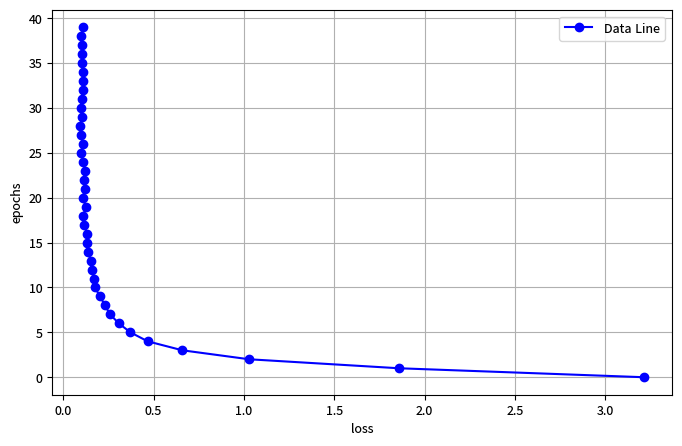

In [12]:
import matplotlib.pyplot as plt

metric = 'loss'
x = [ epoch['valid'][metric] for epoch in result["unit_train_history"] ]
y = range(len(result["unit_train_history"]))
plt.figure(figsize=(8, 5))
plt.plot(x, y, marker='o', linestyle='-', color='b', label='Data Line')

# Add labels, title, and legend
plt.xlabel(metric)
plt.ylabel('epochs')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


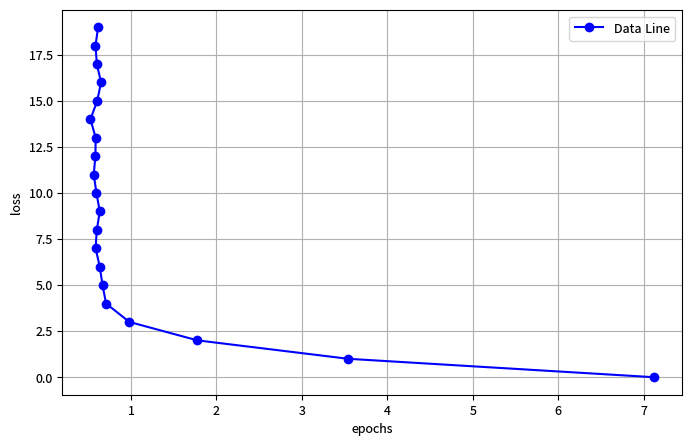

In [13]:
import matplotlib.pyplot as plt

metric = 'loss'
x = [ epoch['valid'][metric] for epoch in result['syll_train_history'] ]
y = range(len(result["syll_train_history"]))
plt.figure(figsize=(8, 5))
plt.plot(x, y, marker='o', linestyle='-', color='b', label='Data Line')


plt.xlabel('epochs')
plt.ylabel(metric)
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


In [14]:
import pickle

with open("train_result_4377_20260427.pkl", "wb") as f:
    pickle.dump(result_history, f)

In [15]:
result['unit_test_metrics']

{'loss': 0.10028314618230388, 'unit_seq_acc': 0.9411764705882353}

In [16]:
result['syll_test_metrics']

{'loss': 0.5254470316695109,
 'top1': 0.8926728367805481,
 'top3': 0.9628483057022095,
 'top5': 0.9772961735725403,
 'top10': 0.9886481165885925}

In [17]:
import numpy as np

train_syll_set = set(train_df["syllable"].astype(str).unique())

test_meta_df_seen = test_df[
    test_df["syllable"].astype(str).isin(train_syll_set)
].copy()

test_seen_ids = set(test_meta_df_seen["sample_index"].astype(int).tolist())

test_emb_df_seen = test_emb_df[
    test_emb_df["sample_index"].isin(test_seen_ids)
].copy()

print("Original Test samples:", test_df["sample_index"].nunique())
print("Seen-only Test samples:", test_meta_df_seen["sample_index"].nunique())
print("Dropped unseen Test samples:", test_df["sample_index"].nunique() - test_meta_df_seen["sample_index"].nunique())

Original Test samples: 2643
Seen-only Test samples: 2550
Dropped unseen Test samples: 93


In [18]:
final_result_history = []
final_result = {}

In [19]:
from nn_unit_syllable_pipeline import run_full_pipeline

model_cfg = result_history[-1]['model_cfg']

unit_train_cfg = result_history[-1]['unit_train_cfg']

syll_train_cfg = result_history[-1]['syll_train_cfg']

result = run_full_pipeline(
    train_emb_df=train_emb_df,
    test_emb_df=test_emb_df_seen,
    train_meta_df=train_df,
    test_meta_df=test_meta_df_seen,
    data_cfg=data_cfg,
    model_cfg=model_cfg,
    unit_train_cfg=unit_train_cfg,
    syll_train_cfg=syll_train_cfg,
    freeze_encoder_for_syll=True,
    save_path="final_unit_syll.pt",
)

final_result['model_cfg'] = model_cfg
final_result['unit_train_cfg'] = unit_train_cfg
final_result['syll_train_cfg'] = syll_train_cfg
final_result_history.append(result)

In [20]:
result['unit_test_metrics']

{'loss': 0.12578496451690502, 'unit_seq_acc': 0.9380392156862745}

In [21]:
result['syll_test_metrics']

{'loss': 0.5057637714287814,
 'top1': 0.9066666960716248,
 'top3': 0.9701960682868958,
 'top5': 0.981176495552063,
 'top10': 0.9878431558609009}

### Save and Load Model

In [16]:
import importlib
import nn_unit_syllable_pipeline
importlib.reload(nn_unit_syllable_pipeline)

from nn_unit_syllable_pipeline import predict_units,predict_syllables,load_pipeline,benchmark_single_sample_runtime,predict_from_emb_df,benchmark_dataset_runtime

In [17]:
pipeline = load_pipeline('baseline_unit_syll.pt')

In [18]:
import copy

# Use CPU for Pi-like inference check
infer_cfg = copy.deepcopy(pipeline["syll_train_cfg"])
infer_cfg.device = "cpu"
infer_cfg.batch_size = 1

pred_df = predict_from_emb_df(
    emb_df=val_emb_df_seen,
    syll_model=pipeline["syll_model"],
    idx2syll=pipeline["idx2syll"],
    data_cfg=pipeline["data_cfg"],
    infer_cfg=infer_cfg,
    sample_meta_df=val_meta_df_seen,   # optional, gives true_syllable
    top_k=10,
)

display(pred_df.head())

,sample_index,pred_top1,pred_topk,pred_topk_prob,true_syllable
0,13,ပါ,"[ပါ, ပဲ, ငါ, ပါရ်, ပါဋ္ဌိ, မှာ, ပါဌ်, ငေါ, ဖာ,...","[0.9999985694885254, 6.107233048169292e-07, 5....",ပါ
1,21,မှာ,"[မှာ, ပာ, ပဋ္ဌာ, ပါရ်, ပါ, ပဏ္ဍာ, ပါ့, ပဲ, ဗန္...","[0.4951888918876648, 0.4764874577522278, 0.027...",မှာ
2,45,တွေ့,"[တွေ့, တွေ, လွေ, စွေ, ရွှေ, လွေ့, ဂွေ့, လှော, ...","[0.6806113123893738, 0.30897411704063416, 0.00...",တွေ
3,49,ရှိ,"[ရှိ, ရှဲ, ညှိ, ရှို, နိ, နှိ, ရှံ, လှိ, ရှ, ရ...","[0.9957246780395508, 0.0024682865478098392, 0....",ရှိ
4,64,ဖြဲ,"[ဖြဲ, ပြစ်, ဖြိုင်, ပျစ်, ဖြု, ဖြစ်, ဖြင်, ပြိ...","[0.6056092977523804, 0.11019250750541687, 0.08...",ဖြစ်


In [19]:
sid = int(val_emb_df_seen["sample_index"].iloc[0])

one_emb_df = val_emb_df_seen[val_emb_df_seen["sample_index"] == sid].copy()
one_meta_df = val_meta_df_seen[val_meta_df_seen["sample_index"] == sid].copy()

bench_df = benchmark_single_sample_runtime(
    one_emb_df,
    syll_model=pipeline["syll_model"],
    idx2syll=pipeline["idx2syll"],
    data_cfg=pipeline["data_cfg"],
    infer_cfg=infer_cfg,
    sample_meta_df=one_meta_df,
    top_k=5,
    runs=20,
)

display(bench_df)


,runs,mean_ms,p50_ms,p95_ms,max_ms
0,20,5.011987,4.935252,5.875373,6.205549


In [20]:
runtime_df = benchmark_dataset_runtime(
    val_emb_df_seen,
    syll_model=pipeline["syll_model"],
    idx2syll=pipeline["idx2syll"],
    data_cfg=pipeline["data_cfg"],
    infer_cfg=infer_cfg,
    sample_meta_df=val_meta_df_seen,
    top_k=5,
    sample_limit=20,
    runs_per_sample=5,
)

display(runtime_df.head())

print("Overall mean ms:", runtime_df["mean_ms"].mean())
print("Overall p95 ms :", np.percentile(runtime_df["mean_ms"], 95))

,runs,mean_ms,p50_ms,p95_ms,max_ms,sample_index
0,5.0,6.157340,5.922500,7.005406,7.180139,2522
1,5.0,5.023949,4.609133,6.561695,6.987370,4003
2,5.0,5.319089,4.851939,6.237352,6.317112,9292
3,5.0,6.257162,6.095703,7.010091,7.013284,10460
4,5.0,5.441306,5.353598,6.389118,6.534897,6698


Overall mean ms: 5.37365611999121
Overall p95 ms : 6.29268790002243


In [21]:
from nn_unit_syllable_pipeline import load_pipeline, build_sample_table, UnitCTCDataset, collate_ctc, predict_units
from torch.utils.data import DataLoader

artifacts = load_pipeline("baseline_unit_syll.pt", map_location="cpu")

unit_model = artifacts["unit_model"]
unit2idx = artifacts["unit2idx"]
idx2unit = artifacts["idx2unit"]
data_cfg = artifacts["data_cfg"]
unit_cfg = artifacts["unit_train_cfg"]

# for Pi-like inference check
unit_cfg.device = "cpu"
unit_cfg.batch_size = 1


In [22]:
unit_sample_table = build_sample_table(
    val_emb_df_seen,
    sample_meta_df=val_meta_df_seen,
    cfg=data_cfg,
    require_units=True,   # unit GT is available
)

display(unit_sample_table)

,sample_index,emb_seq,seq_len,syllable,unit_seq
0,13,"[[-0.019002208, 0.03092773, 0.020762611, 0.033...",3,ပါ,"[ပ, ါ]"
1,21,"[[-0.031382855, -0.008261831, 0.021013161, 0.0...",3,မှာ,"[မ, ှ, ာ]"
2,45,"[[-0.037778948, -0.01735707, 0.026926441, 0.02...",4,တွေ,"[တ, ွ, ေ]"
3,49,"[[0.0057255146, 0.017228125, 0.023403877, 0.03...",3,ရှိ,"[ရ, ှ, ိ]"
4,64,"[[-0.017240943, 0.0052910307, 0.018903978, 0.0...",5,ဖြစ်,"[ဖ, ြ, စ်]"
...,...,...,...,...,...
964,13114,"[[-0.03214562, 0.0034943412, 0.010766525, 0.01...",8,လန်းဒ်,"[လ, န်, း, ဒ်]"
965,13123,"[[-0.029919306, 0.012012148, 0.017131861, 0.01...",7,ဒင်းမ်,"[ဒ, င်, း, မ်]"
966,13131,"[[-0.025450425, 0.0047906684, 0.017245509, 0.0...",9,ကိုင်းလ်,"[က, ိ, ု, င်, း, လ်]"
967,13139,"[[-0.019565461, 0.0055393665, 0.006449724, 0.0...",5,ဗဲ့,"[ဗ, ဲ, ့]"


In [23]:
unit_ds = UnitCTCDataset(unit_sample_table, unit2idx, data_cfg)

unit_loader = DataLoader(
    unit_ds,
    batch_size=unit_cfg.batch_size,
    shuffle=False,
    num_workers=unit_cfg.num_workers,
    collate_fn=collate_ctc,
)

In [24]:
unit_pred_raw = predict_units(
    unit_model,
    unit_loader,
    cfg=unit_cfg,
)

print("num predicted samples:", len(unit_pred_raw))
print(unit_pred_raw[0])

num predicted samples: 969
{'sample_index': 13, 'pred_units_idx': [40, 74], 'syllable_gt': 'ပါ'}


In [25]:
import pandas as pd

def decode_unit_idx_list(idx_list, idx2unit):
    return [idx2unit[int(i)] for i in idx_list]

unit_pred_rows = []
for row in unit_pred_raw:
    sid = int(row["sample_index"])

    gt_row = unit_sample_table[unit_sample_table["sample_index"] == sid].iloc[0]
    gt_units = list(gt_row["unit_seq"])
    pred_units = decode_unit_idx_list(row["pred_units_idx"], idx2unit)

    unit_pred_rows.append({
        "sample_index": sid,
        "syllable": str(gt_row["syllable"]),
        "gt_units": gt_units,
        "pred_units": pred_units,
        "exact_match": pred_units == gt_units,
    })

unit_pred_df = pd.DataFrame(unit_pred_rows)
display(unit_pred_df.head(20))

,sample_index,syllable,gt_units,pred_units,exact_match
0,13,ပါ,"[ပ, ါ]","[ပ, ါ]",True
1,21,မှာ,"[မ, ှ, ာ]","[မ, ှ, ာ]",True
2,45,တွေ,"[တ, ွ, ေ]","[တ, ွ, ေ]",True
3,49,ရှိ,"[ရ, ှ, ိ]","[ရ, ှ, ိ]",True
4,64,ဖြစ်,"[ဖ, ြ, စ်]","[ပ, ြ, စ်]",False
5,105,ခင်,"[ခ, င်]","[ခ, င်]",True
6,122,နိုင်,"[န, ိ, ု, င်]","[န, ိ, င်]",False
7,131,လေး,"[ေလ, း]","[ေယ, း]",False
8,143,ပဲ,"[ပ, ဲ]","[ပ, ဲ]",True
9,161,မယ်,"[မ, ယ်]","[မ, ယ်]",True


In [26]:
unit_seq_acc = unit_pred_df["exact_match"].mean()
print("Unit exact sequence accuracy:", unit_seq_acc)


Unit exact sequence accuracy: 0.9411764705882353


In [27]:
def merge_unit_and_syllable_results(unit_pred_df, pred_df):
    """
    Merge unit-level and syllable-level prediction results by sample_index.
    """
    # keep only needed syllable cols
    keep_cols = ["sample_index", "pred_top1"]
    if "true_syllable" in pred_df.columns:
        keep_cols.append("true_syllable")
    if "pred_topk" in pred_df.columns:
        keep_cols.append("pred_topk")

    merged = unit_pred_df.merge(
        pred_df[keep_cols],
        on="sample_index",
        how="inner",
        validate="one_to_one",
    )

    # unify true syllable column
    if "true_syllable" not in merged.columns:
        merged["true_syllable"] = merged["syllable"]

    # syllable correctness
    merged["syllable_correct"] = (
        merged["pred_top1"].astype(str) == merged["true_syllable"].astype(str)
    )

    # rename for clarity
    merged["unit_correct"] = merged["exact_match"].astype(bool)

    return merged

In [28]:
merged_df = merge_unit_and_syllable_results(unit_pred_df, pred_df)
display(merged_df.head())

,sample_index,syllable,gt_units,pred_units,exact_match,pred_top1,true_syllable,pred_topk,syllable_correct,unit_correct
0,13,ပါ,"[ပ, ါ]","[ပ, ါ]",True,ပါ,ပါ,"[ပါ, ပဲ, ငါ, ပါရ်, ပါဋ္ဌိ, မှာ, ပါဌ်, ငေါ, ဖာ,...",True,True
1,21,မှာ,"[မ, ှ, ာ]","[မ, ှ, ာ]",True,မှာ,မှာ,"[မှာ, ပာ, ပဋ္ဌာ, ပါရ်, ပါ, ပဏ္ဍာ, ပါ့, ပဲ, ဗန္...",True,True
2,45,တွေ,"[တ, ွ, ေ]","[တ, ွ, ေ]",True,တွေ့,တွေ,"[တွေ့, တွေ, လွေ, စွေ, ရွှေ, လွေ့, ဂွေ့, လှော, ...",False,True
3,49,ရှိ,"[ရ, ှ, ိ]","[ရ, ှ, ိ]",True,ရှိ,ရှိ,"[ရှိ, ရှဲ, ညှိ, ရှို, နိ, နှိ, ရှံ, လှိ, ရှ, ရ...",True,True
4,64,ဖြစ်,"[ဖ, ြ, စ်]","[ပ, ြ, စ်]",False,ဖြဲ,ဖြစ်,"[ဖြဲ, ပြစ်, ဖြိုင်, ပျစ်, ဖြု, ဖြစ်, ဖြင်, ပြိ...",False,False


In [29]:
def assign_error_case(merged_df):
    """
    Add 4-case error category:
      - unit_correct_syllable_correct
      - unit_correct_syllable_wrong
      - unit_wrong_syllable_correct
      - unit_wrong_syllable_wrong
    """
    df = merged_df.copy()

    def _case(row):
        if row["unit_correct"] and row["syllable_correct"]:
            return "unit_correct_syllable_correct"
        elif row["unit_correct"] and not row["syllable_correct"]:
            return "unit_correct_syllable_wrong"
        elif (not row["unit_correct"]) and row["syllable_correct"]:
            return "unit_wrong_syllable_correct"
        else:
            return "unit_wrong_syllable_wrong"

    df["case"] = df.apply(_case, axis=1)
    return df

In [30]:
merged_df = assign_error_case(merged_df)
display(merged_df.head())

,sample_index,syllable,gt_units,pred_units,exact_match,pred_top1,true_syllable,pred_topk,syllable_correct,unit_correct,case
0,13,ပါ,"[ပ, ါ]","[ပ, ါ]",True,ပါ,ပါ,"[ပါ, ပဲ, ငါ, ပါရ်, ပါဋ္ဌိ, မှာ, ပါဌ်, ငေါ, ဖာ,...",True,True,unit_correct_syllable_correct
1,21,မှာ,"[မ, ှ, ာ]","[မ, ှ, ာ]",True,မှာ,မှာ,"[မှာ, ပာ, ပဋ္ဌာ, ပါရ်, ပါ, ပဏ္ဍာ, ပါ့, ပဲ, ဗန္...",True,True,unit_correct_syllable_correct
2,45,တွေ,"[တ, ွ, ေ]","[တ, ွ, ေ]",True,တွေ့,တွေ,"[တွေ့, တွေ, လွေ, စွေ, ရွှေ, လွေ့, ဂွေ့, လှော, ...",False,True,unit_correct_syllable_wrong
3,49,ရှိ,"[ရ, ှ, ိ]","[ရ, ှ, ိ]",True,ရှိ,ရှိ,"[ရှိ, ရှဲ, ညှိ, ရှို, နိ, နှိ, ရှံ, လှိ, ရှ, ရ...",True,True,unit_correct_syllable_correct
4,64,ဖြစ်,"[ဖ, ြ, စ်]","[ပ, ြ, စ်]",False,ဖြဲ,ဖြစ်,"[ဖြဲ, ပြစ်, ဖြိုင်, ပျစ်, ဖြု, ဖြစ်, ဖြင်, ပြိ...",False,False,unit_wrong_syllable_wrong


In [31]:
def summarize_error_cases(merged_df):
    out = (
        merged_df["case"]
        .value_counts(dropna=False)
        .rename_axis("case")
        .reset_index(name="count")
    )
    out["ratio"] = out["count"] / len(merged_df)
    return out

In [32]:
case_summary_df = summarize_error_cases(merged_df)
display(case_summary_df)

,case,count,ratio
0,unit_correct_syllable_correct,844,0.871001
1,unit_correct_syllable_wrong,68,0.070175
2,unit_wrong_syllable_wrong,36,0.037152
3,unit_wrong_syllable_correct,21,0.021672


In [33]:
def split_error_cases(merged_df):
    return {
        "unit_correct_syllable_correct": merged_df[
            (merged_df["unit_correct"]) & (merged_df["syllable_correct"])
        ].copy(),

        "unit_correct_syllable_wrong": merged_df[
            (merged_df["unit_correct"]) & (~merged_df["syllable_correct"])
        ].copy(),

        "unit_wrong_syllable_correct": merged_df[
            (~merged_df["unit_correct"]) & (merged_df["syllable_correct"])
        ].copy(),

        "unit_wrong_syllable_wrong": merged_df[
            (~merged_df["unit_correct"]) & (~merged_df["syllable_correct"])
        ].copy(),
    }

In [34]:
case_summary_df.to_clipboard(index=False)

In [35]:
case_dict = split_error_cases(merged_df)

for name, df in case_dict.items():
    print(name, len(df))

unit_correct_syllable_correct 844
unit_correct_syllable_wrong 68
unit_wrong_syllable_correct 21
unit_wrong_syllable_wrong 36


In [36]:
def show_case(df, n=20):
    cols = [
        "sample_index",
        "true_syllable",
        "pred_top1",
        "gt_units",
        "pred_units",
        "unit_correct",
        "syllable_correct",
        "case",
    ]

    cols = [c for c in cols if c in df.columns]
    return df[cols].head(n)

In [37]:
display(show_case(case_dict["unit_correct_syllable_wrong"], n=20))

,sample_index,true_syllable,pred_top1,gt_units,pred_units,unit_correct,syllable_correct,case
2,45,တွေ,တွေ့,"[တ, ွ, ေ]","[တ, ွ, ေ]",True,False,unit_correct_syllable_wrong
16,194,ဗျား,ဖျား,"[ဗ, ျ, ာ, း]","[ဗ, ျ, ာ, း]",True,False,unit_correct_syllable_wrong
18,228,နာ,နှာ,"[န, ာ]","[န, ာ]",True,False,unit_correct_syllable_wrong
52,707,ရုံ,ရုင်,"[ရ, ု, ံ]","[ရ, ု, ံ]",True,False,unit_correct_syllable_wrong
64,867,နော်,နော့်,"[ေန, ာ, ်]","[ေန, ာ, ်]",True,False,unit_correct_syllable_wrong
71,985,ရောင်,ရောင့်,"[ေရ, ာ, င်]","[ေရ, ာ, င်]",True,False,unit_correct_syllable_wrong
83,1127,လျှောက်,လှောက်,"[လ, ျ, ှ, ေ, ာ, က်]","[လ, ျ, ှ, ေ, ာ, က်]",True,False,unit_correct_syllable_wrong
107,1506,သင့်,သင့်,"[သ, င်, ့]","[သ, င်, ့]",True,False,unit_correct_syllable_wrong
115,1585,မိတ်,ပြိန်,"[မ, ိ, တ်]","[မ, ိ, တ်]",True,False,unit_correct_syllable_wrong
139,1973,ပြုံး,ဗြုံး,"[ပ, ြ, ု, ံ, း]","[ပ, ြ, ု, ံ, း]",True,False,unit_correct_syllable_wrong


In [ ]:
pd.DataFrame.to_clipboard

In [43]:
show_case(case_dict["unit_wrong_syllable_wrong"], n=5).to_clipboard()

In [38]:
display(show_case(case_dict["unit_wrong_syllable_correct"], n=20))

,sample_index,true_syllable,pred_top1,gt_units,pred_units,unit_correct,syllable_correct,case
6,122,နိုင်,နိုင်,"[န, ိ, ု, င်]","[န, ိ, င်]",False,True,unit_wrong_syllable_correct
22,276,စု,စု,"[စ, ု]",[ရ],False,True,unit_wrong_syllable_correct
34,442,နှင့်,နှင့်,"[န, ှ, င်, ့]","[ဒ, င်, ့]",False,True,unit_wrong_syllable_correct
127,1803,ခွေး,ခွေး,"[ခ, ွ, ေ, း]","[ဒ, ွ, ေ, း]",False,True,unit_wrong_syllable_correct
243,3494,တင့်,တင့်,"[တ, င်, ့]","[တ, င, ့, ်]",False,True,unit_wrong_syllable_correct
308,4365,ယောက်ျား,ယောက်ျား,"[ေယ, ာ, က်, ျ, ာ, း]","[ေယ, ာ, က်, ု, ာ, း]",False,True,unit_wrong_syllable_correct
399,5533,နန္ဒ,နန္ဒ,"[န, န, ္ဒ]","[န, ္ဒ]",False,True,unit_wrong_syllable_correct
400,5534,နန္ဒ,နန္ဒ,"[န, န, ္ဒ]","[န, ္ဒ]",False,True,unit_wrong_syllable_correct
411,5653,လှည့်,လှည့်,"[လ, ှ, ည, ့, ်]","[လ, ှ, ည်, ်]",False,True,unit_wrong_syllable_correct
416,5714,ပေ့,ပေ့,"[ေပ, ့]","[ေမ, ့]",False,True,unit_wrong_syllable_correct


In [39]:
display(show_case(case_dict["unit_wrong_syllable_wrong"], n=20))

,sample_index,true_syllable,pred_top1,gt_units,pred_units,unit_correct,syllable_correct,case
4,64,ဖြစ်,ဖြဲ,"[ဖ, ြ, စ်]","[ပ, ြ, စ်]",False,False,unit_wrong_syllable_wrong
7,131,လေး,ကေး,"[ေလ, း]","[ေယ, း]",False,False,unit_wrong_syllable_wrong
15,193,ဗျား,ပျား,"[ဗ, ျ, ာ, း]","[ပ, ျ, ာ, း]",False,False,unit_wrong_syllable_wrong
20,266,လောက်,ယောက်,"[ေလ, ာ, က်]","[ေယ, ာ, က်]",False,False,unit_wrong_syllable_wrong
28,361,ဝင်,ဝဂ်,"[ဝ, င်]","[ဝ, ဂ်]",False,False,unit_wrong_syllable_wrong
45,603,ဘ,သ,[ဘ],[သ],False,False,unit_wrong_syllable_wrong
106,1486,မက်,ဏက်,"[မ, က်]","[ဏ, က်]",False,False,unit_wrong_syllable_wrong
131,1828,ကျန်း,ကျန်,"[က, ျ, န်, း]","[က, ျ, န်]",False,False,unit_wrong_syllable_wrong
156,2170,လျှော့,လှုံ့,"[လ, ျ, ှ, ေ, ာ, ့]","[လ, ျ, ှ, ာ, ့]",False,False,unit_wrong_syllable_wrong
206,2956,ပံ့,ဗု,"[ပ, ံ, ့]","[ပ, ီ, ့]",False,False,unit_wrong_syllable_wrong
